<a href="https://colab.research.google.com/github/Kinosaurus/PyTorch-Projects/blob/main/Chest_CT_Scan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Link: https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images/data

In [1]:
from google.colab import drive
import gc

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import kagglehub
from pathlib import Path
import os

path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-ctscan-images' dataset.
Path to dataset files: /kaggle/input/chest-ctscan-images


In [3]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

torch version: 2.13.0+cu130
torchvision version: 0.28.0+cu130


In [4]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

In [5]:
import requests

with open("data_setup.py", "wb") as f:
  request = requests.get("https://github.com/Kinosaurus/PyTorch-Projects/raw/refs/heads/main/data_setup.py")
  f.write(request.content)

with open("engine.py", "wb") as f:
  request = requests.get("https://github.com/Kinosaurus/PyTorch-Projects/raw/refs/heads/main/engine.py")
  f.write(request.content)

with open("helper_functions.py", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/helper_functions.py")
  f.write(request.content)

In [6]:
import data_setup, engine, helper_functions

In [7]:
# Viewing nested directories in path
for p in os.walk(path):
  print(p)

('/kaggle/input/chest-ctscan-images', ['Data'], [])
('/kaggle/input/chest-ctscan-images/Data', ['valid', 'test', 'train'], [])
('/kaggle/input/chest-ctscan-images/Data/valid', ['squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib'], [])
('/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa', [], ['000115 (2).png', '000115 (5).png', '000112.png', '000118 (5).png', '000117 (4).png', '000114 (6).png', '000117 (6).png', '000114 (4).png', '000118 (4).png', '000119.png', '000116 (2).png', '000110 (6).png', '000108 (3).png', '000111.png', '000119 (5).png'])
('/kaggle/input/chest-ctscan-images/Data/valid/normal', [], ['003828_02_01_174.png', '6 - Copy.png', '6 - Copy (2) - Copy.png', '6 - Copy (3).png', '4 - Copy (2).png', '7.png', '5.png', '4 (2).png', '004162_01_01_150.png', '004007_01_01_519.png', '8 - Copy (3).png', '7 - Copy (2).png', '7 - Copy (3

In [8]:
# Setup data path
data_path = Path(path) / "Data"

# Walking through Data dir
helper_functions.walk_through_dir(data_path)

There are 3 directories and 0 images in '/kaggle/input/chest-ctscan-images/Data'.
There are 4 directories and 0 images in '/kaggle/input/chest-ctscan-images/Data/valid'.
There are 0 directories and 15 images in '/kaggle/input/chest-ctscan-images/Data/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'.
There are 0 directories and 13 images in '/kaggle/input/chest-ctscan-images/Data/valid/normal'.
There are 0 directories and 21 images in '/kaggle/input/chest-ctscan-images/Data/valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa'.
There are 0 directories and 23 images in '/kaggle/input/chest-ctscan-images/Data/valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib'.
There are 4 directories and 0 images in '/kaggle/input/chest-ctscan-images/Data/test'.
There are 0 directories and 90 images in '/kaggle/input/chest-ctscan-images/Data/test/squamous.cell.carcinoma'.
There are 0 directories and 54 images in '/kaggle/input/chest-ctscan-images/Data/test/normal'.
There are 0 directories and 120 ima

In [9]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

In [10]:
# Check hardware specifications
!nvidia-smi

Thu Aug  6 15:37:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
# Setup train and test directories
train_dir = data_path / "train"
test_dir = data_path / "test"

# Auto Transform - replicating Efficient_Net_V2_S default transformations

In [12]:
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s

# Setup weights
weights = EfficientNet_V2_S_Weights.DEFAULT

# Get transformation
auto_transform = weights.transforms()

# EfficientNet_V2_S Model with Manual Transform

In [22]:
auto_transform

ImageClassification(
    crop_size=[384]
    resize_size=[384]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [23]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

augment_transform = transforms.Compose([
    # Perform transformation on PIL image
    transforms.Resize(size=384, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(size=384),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    # transforms.RandomHorizontalFlip(),
    # transforms.AugMix(),
    # Convert to Tensor
    transforms.ToTensor(),
    # Normalisation of Vector Elements
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

augment_transform

Compose(
    Resize(size=384, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(384, 384))
    TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

In [24]:
# Create dataloaders
BATCH_SIZE=32

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transform=augment_transform,
    test_transform=auto_transform,
    batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7fc56de4a960>,
 ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
  'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
  'normal',
  'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa'])

## Setting up Weights and Biases Sweep Experiment to Find Optimum Learning Rate

In [25]:
import torch
import wandb

# Define sweep
sweep_config = {
  "method": "bayes",
  "metric": {
    "goal": "minimize",
    "name": "test_loss"
  },
  "parameters": {
    "epochs": {
      "values": [30]
    },

    "learning_rate": {
      "values": [
        0.1,
        0.01,
        0.001
      ]
    }
  }
}

# Create sweep
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project="CT-Scan-Models"
)

print("Sweep ID", sweep_id)

In [26]:
# Sweep Train function
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s

def sweep_train():
  with wandb.init() as run:
    # Get hyperparameters from W&B
    config = wandb.config

    epochs = config.epochs
    learning_rate = config.learning_rate

    print("\n" + "-" * 50)
    print("Starting new sweep run")
    print("\n" + "-" * 50)

    torch.manual_seed(42)
    torch.cuda.manual_seed(42)

    # Setup weights
    weights = EfficientNet_V2_S_Weights.DEFAULT

    # Load model
    model_manual_transform = efficientnet_v2_s(weights=weights)

    # Customise classifier layer
    output_shape = len(class_names)
    model_manual_transform.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features=1280, out_features=output_shape, bias=True)
    )
    # Freeze model base layers
    for param in model_manual_transform.features.parameters():
      param.requires_grad = False

    # Setup Optimiser, Loss Function
    optimiser = torch.optim.Adam(model_manual_transform.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    # Training the model
    results = engine.train(
      model=model_manual_transform,
      train_dataloader=train_dataloader,
      test_dataloader=test_dataloader,
      optimizer=optimiser,
      loss_fn=loss_fn,
      epochs=epochs,
      device=device,
    )
    # Logging results to W&B
    for epoch in range(epochs):
      wandb.log({
        "epoch": epoch+1,
        "train_loss": results["train_loss"][epoch],
        "train_acc": results["train_acc"][epoch],
        "test_loss": results["test_loss"][epoch],
        "test_acc": results["test_acc"][epoch]
      })

# Start sweep
wandb.agent(
    sweep_id=sweep_id,
    function=sweep_train,
    count=3
)

## Fine-tuning

In [43]:
# Setup model dir
models_dir = Path("drive") / "MyDrive" / "PyTorch" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

In [44]:
# # Uncomment if creating new model instance, loading saved state dicts
from torchvision.models import EfficientNet_V2_S_Weights, efficientnet_v2_s

torch.manual_seed(42)
torch.cuda.manual_seed(42)

weights = EfficientNet_V2_S_Weights.DEFAULT
model_manual_transform = efficientnet_v2_s(weights=weights)
# model_manual_transform.load_state_dict()

In [45]:
# Setup Optimiser, Loss Function
optimiser = torch.optim.SGD(model_manual_transform.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

In [46]:
# Loading best state dict
best_state_dict = torch.load(models_dir / "5_Aug_Best.pth", map_location="cpu", weights_only=True, mmap=True)
model_manual_transform.load_state_dict(best_state_dict, assign=True)

<All keys matched successfully>

In [47]:
del best_state_dict
# Python garbage collection
gc.collect()

18

In [48]:
model_manual_transform = model_manual_transform.to(device)
# Clear PyTorch CUDA cache
torch.cuda.empty_cache()

# Training the model
manual_results = engine.train(
    model=model_manual_transform,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimiser,
    loss_fn=loss_fn,
    epochs=50,
    device=device,
)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | Learning Rate: 9.990133642141359e-05 | Train Loss: 0.0915 | Train Accuracy: 0.9703 | Test Loss: 0.3275 | Test Accuracy 0.8963
Epoch: 2 | Learning Rate: 9.96057350657239e-05 | Train Loss: 0.1200 | Train Accuracy: 0.9519 | Test Loss: 0.3579 | Test Accuracy 0.8900
Epoch: 3 | Learning Rate: 9.911436253643444e-05 | Train Loss: 0.0685 | Train Accuracy: 0.9797 | Test Loss: 0.3424 | Test Accuracy 0.8988
Epoch: 4 | Learning Rate: 9.842915805643155e-05 | Train Loss: 0.0711 | Train Accuracy: 0.9766 | Test Loss: 0.3425 | Test Accuracy 0.8926
Epoch: 5 | Learning Rate: 9.755282581475769e-05 | Train Loss: 0.0815 | Train Accuracy: 0.9703 | Test Loss: 0.3304 | Test Accuracy 0.8963
Epoch: 6 | Learning Rate: 9.648882429441257e-05 | Train Loss: 0.0989 | Train Accuracy: 0.9628 | Test Loss: 0.3567 | Test Accuracy 0.8994
Epoch: 7 | Learning Rate: 9.524135262330098e-05 | Train Loss: 0.0783 | Train Accuracy: 0.9781 | Test Loss: 0.3684 | Test Accuracy 0.8869
Epoch: 8 | Learning Rate: 9.38153340021931

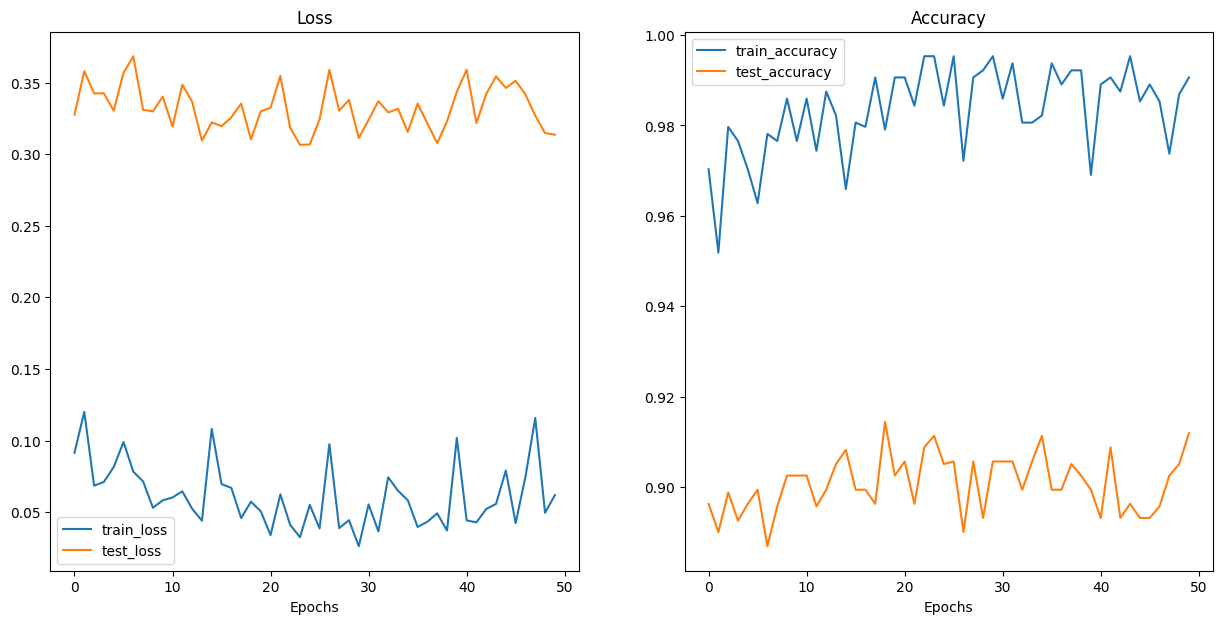

In [49]:
helper_functions.plot_loss_curves(manual_results)

In [50]:
# Get best state dict
import numpy as np

best_model_idx = np.argmin(np.array(manual_results["test_loss"]))
best_state_dict = manual_results["state_dict"][best_model_idx]

# model_manual_transform.load_state_dict(best_state_dict)

In [51]:
# Saving best performing model's state dict
torch.save(best_state_dict, models_dir /"7_Aug_Best_.pth")

## Visualising Predictions on Random Images

In [52]:
class_names

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

In [80]:
class_names_list = ["adenocarcinoma", "large.cell", "normal", "squamous.cell"]

Text(0.5, 0.98, 'CT Scan Image Classification (Red=Incorrect, Green=Correct)')

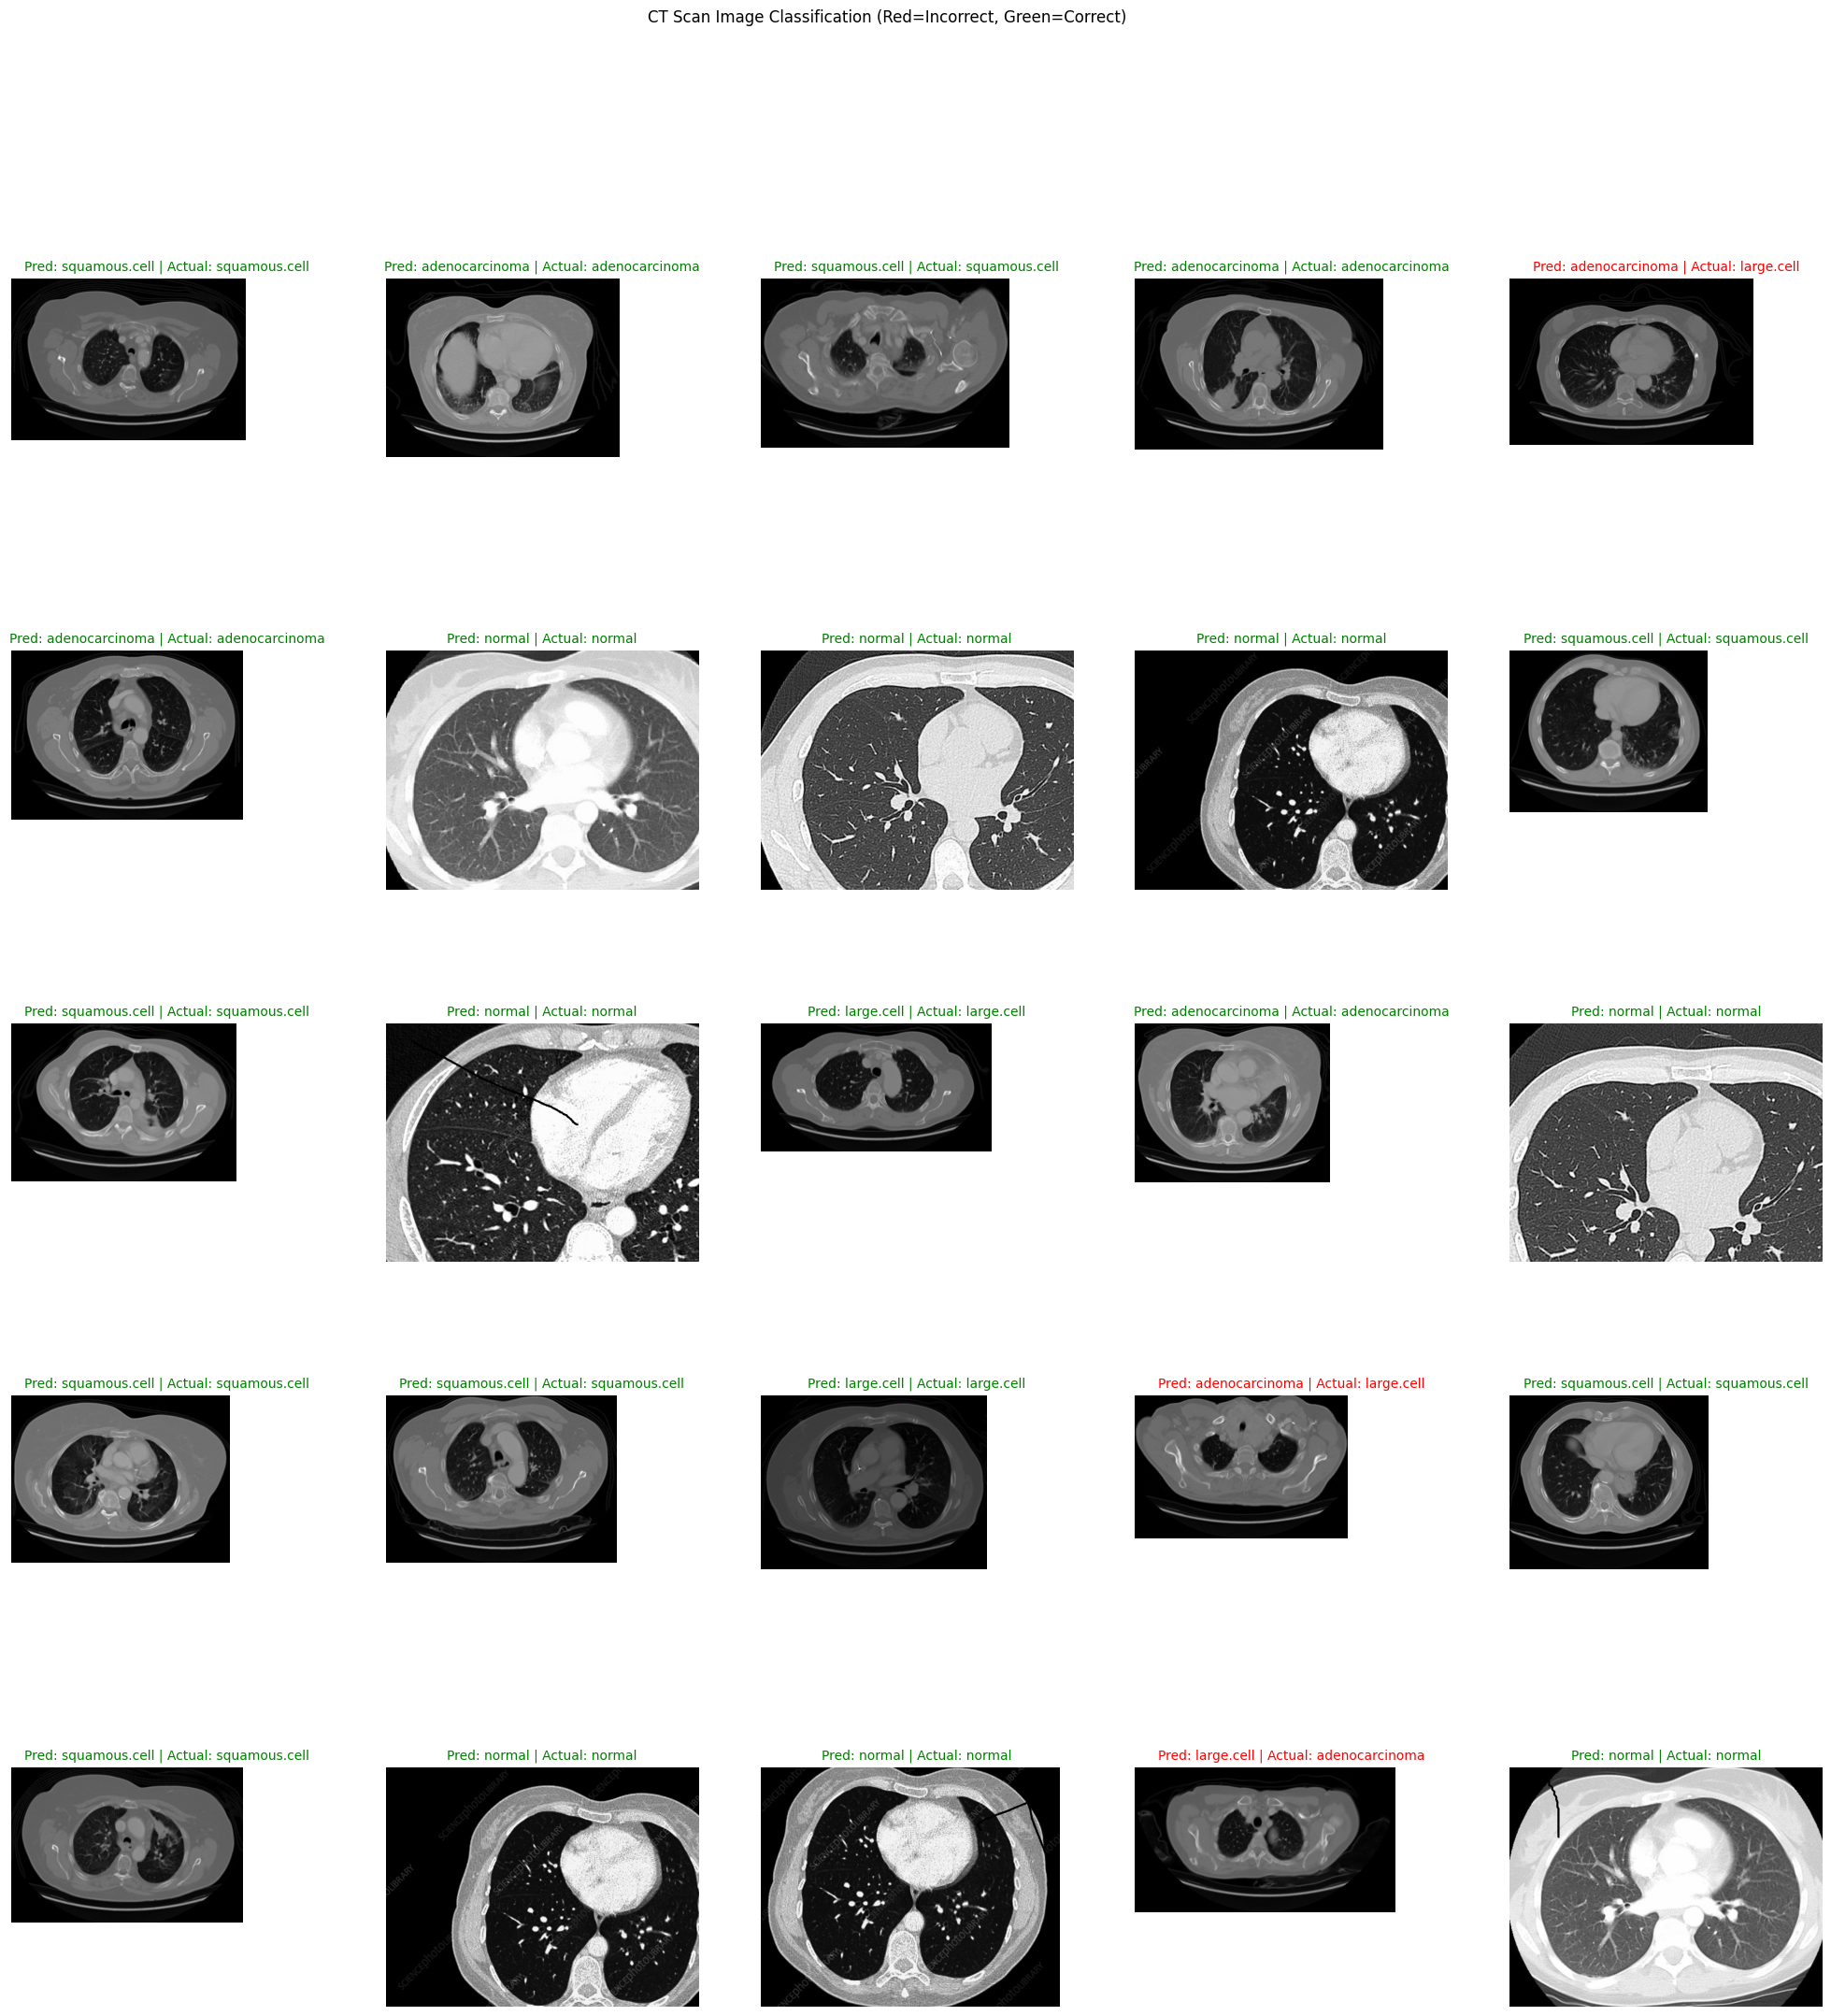

In [84]:
import random, PIL
import matplotlib.pyplot as plt

# Setting up plt subplots
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True, figsize=(25, 25))

test_images_path = [i for i in test_dir.glob("*/*.png")]
test_images_path

random_samples = random.sample(test_images_path, k=25)

for idx, sample in enumerate(random_samples):
  col = idx % 5
  row = idx // 5
  actual_label = sample.parent.stem
  with PIL.Image.open(sample).convert("RGB") as img:
    # Image -> Transformed Tensor
    transformed_image = auto_transform(img).to(device)
    # Turn on eval mode
    model_manual_transform.eval()
    # Inference mode
    with torch.inference_mode():
      # Forward pass
      pred_logit = model_manual_transform(transformed_image.unsqueeze(0))
      pred_label = class_names_list[pred_logit.argmax(dim=1)]
      # print(actual_label)
      # print(pred_label)
      ax[row, col].imshow(img)
      ax[row, col].set_title(f"Pred: {pred_label} | Actual: {actual_label}", fontsize=10, color="green" if (pred_label==actual_label) else "red")
      ax[row, col].axis(False)
fig.suptitle("CT Scan Image Classification (Red=Incorrect, Green=Correct)")

## Evaluating Model using Confusion Matrix

In [82]:
actual_label_list, pred_label_list = [], []

for idx, test_image in enumerate(test_images_path):
  actual_label = class_names_list.index(test_image.parent.stem)
  actual_label_list.append(actual_label)
  with PIL.Image.open(test_image).convert("RGB") as img:
    # Image -> Transformed Tensor
    transformed_image = auto_transform(img).to(device)
    # Turn on eval mode
    model_manual_transform.eval()
    # Inference mode
    with torch.inference_mode():
      # Forward pass
      pred_logit = model_manual_transform(transformed_image.unsqueeze(0))
      pred_label = pred_logit.argmax(dim=1)
      pred_label_list.append(pred_label.item())

actual_label_list = torch.tensor(actual_label_list)
pred_label_list = torch.tensor(pred_label_list)

actual_label_list, pred_label_list

(tensor([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
         3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1

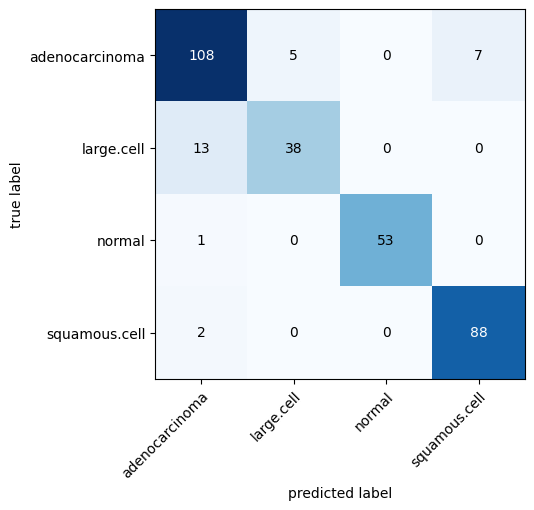

In [85]:
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

try:
  from torchmetrics import ConfusionMatrix
except:
  !pip install torchmetrics
  from torchmetrics import ConfusionMatrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
multiclass = confmat(pred_label_list, actual_label_list)

fig, ax = plot_confusion_matrix(conf_mat=multiclass.numpy(),
                                class_names=class_names_list)
plt.show()